# Simple model

For this simple model, we simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC sampling.

In [1]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

from src.MCMC.helpers import gen_parameter_labels
from src.MCMC.plotting import plot_1d_hist, plot_trace
from src.MCMC.posterior import log_posterior, log_likelihood
from src.MCMC.priors import UniformPrior

from src.simulator import BurstSimulator, Model
from src.helpers import plot_posterior_samples

In [2]:
# defining the priors
def get_prior_dict(N):
    prior_dict = {
        "t0"  : UniformPrior(x_min=0,    x_max=1,   log=False, enforce_order=True, dim=N),
        "amp" : UniformPrior(x_min=10,   x_max=300, log=False,  enforce_order=False, dim=N),
        "rise": UniformPrior(x_min=1e-3, x_max=1,  log=True, enforce_order=False, dim=N),
        "skew": UniformPrior(x_min=1,    x_max=6,   log=False, enforce_order=False, dim=N)
    }
    return prior_dict

In [3]:
time = np.linspace(0, 1.0, 1000)

N = 1
inf_params = ["t0"]

# ground-truth
amp  = 100.0
t0   = 0.4
rise = 0.03
skew = 5.0

burstparams = {
    't0'   : [t0],
    'amp'  : [amp],
    'rise' : [rise],
    'skew' : [skew]
}

ybkg = 5.0

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
noise_free_model, simulated_counts = simulator.simulate_burst(return_model=True)

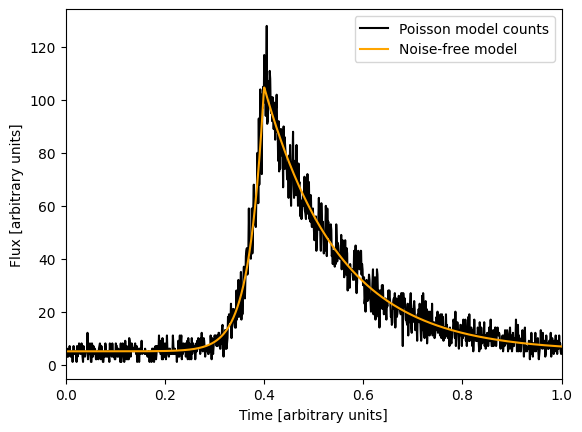

In [4]:
simulator.plot_burst()
plt.show()

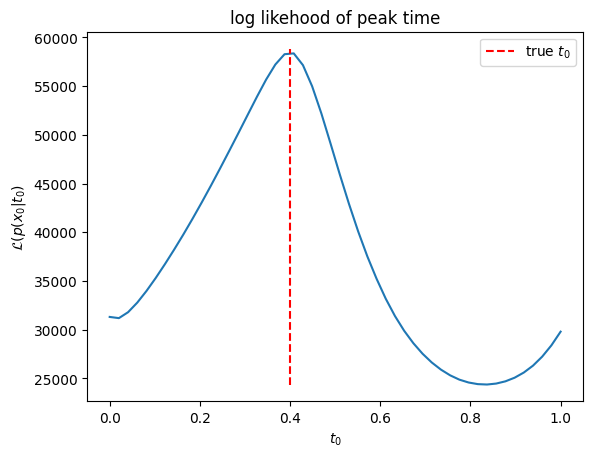

In [5]:
true_t0 = simulator.get_true('t0')

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

prior_dict = get_prior_dict(N)

t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood([t0], inf_params, prior_dict, modelparams, simulated_counts) for t0 in t0s]

plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()

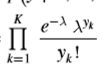

In [6]:
nwalkers = 20
ndim = len(inf_params) * N

p0 = [prior_dict[key].sample(nwalkers) for key in inf_params]
p0 = np.concatenate(p0, axis=1)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[inf_params, prior_dict, modelparams, simulated_counts])

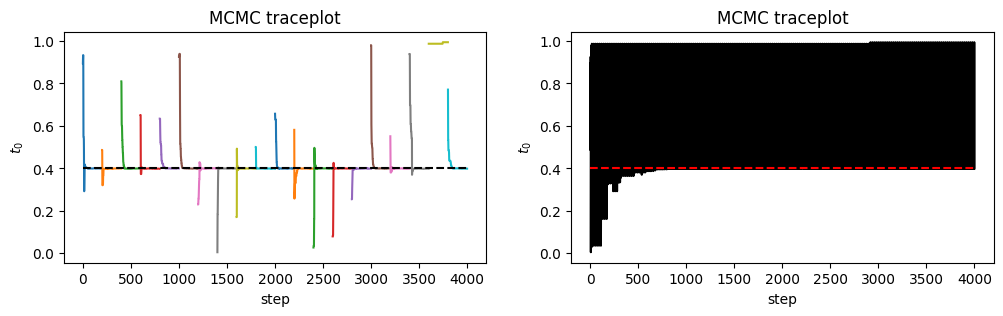

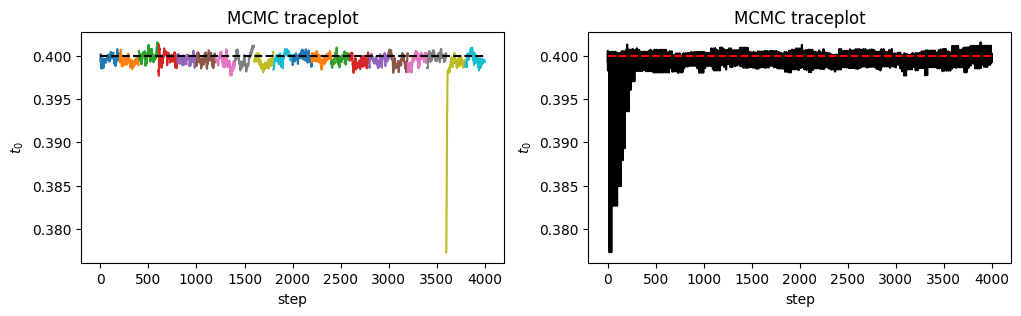

In [7]:
# burn-in 
burn_steps = 200
state = sampler.run_mcmc(p0, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

# correct walkers with low likelihood (otherwise likely to get stuck)
rounded_probs = 1000 * np.floor(state.log_prob / 1000)
low_prob_mask = state.log_prob < np.max(rounded_probs)

variations      = np.ones((sum(low_prob_mask), ndim)) * np.random.uniform(low=0.9, high=1.1, size=(sum(low_prob_mask), ndim))
most_likely_pos = state.coords[np.argmax(state.log_prob)]
state.coords[low_prob_mask] = most_likely_pos * variations

# burn-in with repositioned walkers 
state = sampler.run_mcmc(state, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

In [8]:
steps = 1000
sampler.run_mcmc(state, 1000, progress=True)

100%|██████████| 1000/1000 [00:02<00:00, 369.96it/s]


State([[0.40049773]
 [0.39956825]
 [0.39942633]
 [0.39966633]
 [0.39924948]
 [0.3995983 ]
 [0.39992772]
 [0.39963589]
 [0.39966516]
 [0.39914535]
 [0.39891165]
 [0.39976219]
 [0.3995565 ]
 [0.39941827]
 [0.39996956]
 [0.39877464]
 [0.39926404]
 [0.39918672]
 [0.40023055]
 [0.40071696]], log_prob=[58486.88135433 58488.21198043 58488.14998352 58488.21447053
 58488.01103537 58488.21624136 58488.06090631 58488.21721987
 58488.21463527 58487.88369588 58487.46456158 58488.18515077
 58488.20947317 58488.14438067 58488.01479713 58487.13262566
 58488.02593419 58487.93866003 58487.59383346 58486.05160113], blobs=None, random_state=('MT19937', array([2943543105,  292575514,  444231626, 3489934486, 2330887809,
       1591483415,  768908517, 1880688542, 3030361917, 2485426830,
       3720287025, 1707516939, 1550528385, 1540818346, 1395767223,
        403290362, 3958423875, 3053601736, 3586956387, 1737556890,
        785574593, 2692028282, 1588464665, 2837199910, 2930438360,
       2188302051,    10

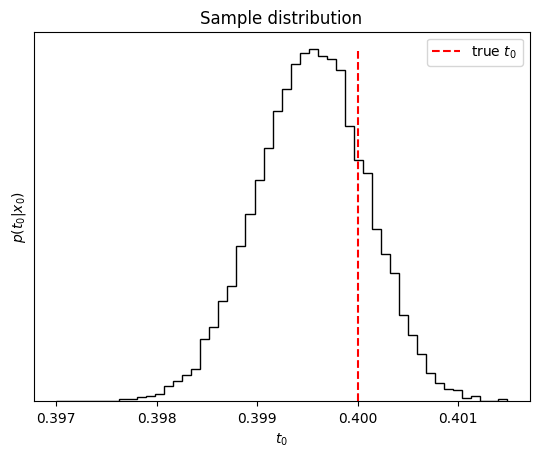

In [9]:
samples = sampler.get_chain(flat=True)

plt.figure()
plot_1d_hist(samples, true_t0)

In [10]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check

Mean acceptance fraction: 0.810


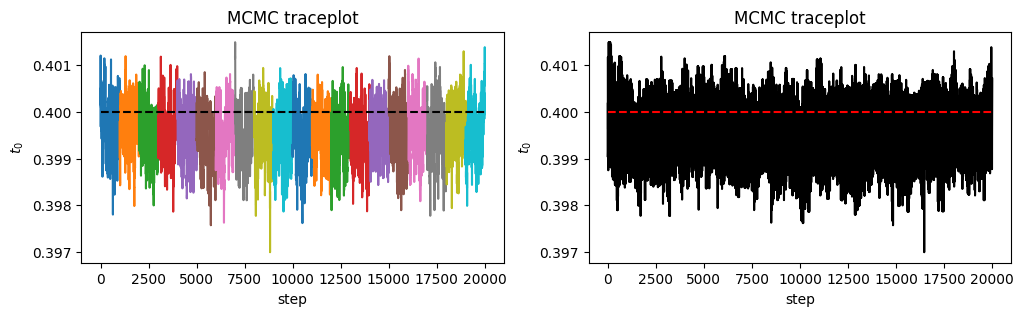

In [11]:
# trace plot
plot_trace(sampler, steps, true_t0)
plt.show()